# Programación Genética: robot repartidor de galletas y detección de fraudes


1. **Ejercicio 2, robot repartidor de galletas.** Un robot recorre una sala cuadrada entregando galletas a un grupo de ingenieros. La PG evoluciona el programa que controla sus movimientos.
2. **Ejercicio 3, detección de fraudes.** Se genera un archivo de transacciones (monto, hora, distancia a la casa, ingreso mensual, fraude sí/no), se revisa para que sea más realista y se evoluciona un modelo que detecte fraudes.

Se usa [DEAP](https://deap.readthedocs.io/) para los árboles, el cruce, la mutación y el ciclo evolutivo. Las semillas están fijas, así que al correr todo de arriba a abajo salen los mismos resultados (siempre que las versiones de las librerías sean las de `requirements.txt`).

## 0. Configuración


In [ ]:
try:
    import deap
except ImportError:
    %pip install -q deap

In [ ]:
import os, random, operator, time, warnings, re, copy
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deap import base, creator, gp, tools, algorithms

warnings.filterwarnings("ignore")            # DEAP avisa que las constantes aleatorias no se pueden serializar; no afecta nada acá
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# Carpetas de salida: el CSV de fraudes va a data/ y las figuras principales a img/
os.makedirs("data", exist_ok=True)
os.makedirs("img", exist_ok=True)
def guardar(fig, nombre):
    fig.savefig(f"img/{nombre}.png", dpi=130, bbox_inches="tight")

## 1. La PG en pocas palabras

**Idea.** En un algoritmo genético clásico el cromosoma es una lista de números. En **programación genética (PG)** el individuo es un **programa**, representado como un **árbol**: los nodos internos son *funciones* (`+`, `*`, `if`...) y las hojas son *terminales* (variables, constantes o acciones). Lo que evoluciona es el programa completo.

**El ciclo** es el mismo de cualquier algoritmo evolutivo:

1. Crear una población inicial de árboles aleatorios.
2. Ejecutar cada árbol y medir su **aptitud** (qué tan bien resuelve el problema).
3. Elegir padres con más probabilidad para los más aptos.
4. Crear la nueva generación con **cruce** (intercambiar subárboles entre dos padres) y **mutación** (cambiar un pedazo de un árbol).
5. Repetir hasta cumplir el criterio de parada. El mejor individuo visto es el resultado.

**Qué hay que definir para cualquier problema** (los "pasos preparatorios" de la guía):

| Paso | Qué es | Dónde aparece en DEAP |
|---|---|---|
| Problema | Qué se quiere resolver | (tú lo defines) |
| Terminales | Hojas del árbol: variables, constantes, acciones | `PrimitiveSet`, `addTerminal`, argumentos |
| Funciones | Nodos internos, cada una con su aridad (número de argumentos) | `addPrimitive` |
| Aptitud | Número que dice qué tan bueno es un árbol | función `evaluate` |
| Parámetros | Tamaño de población, generaciones, prob. de cruce y mutación, selección | `eaSimple`, `selTournament`... |
| Resultado y parada | Cuándo se detiene y cuál árbol se entrega | `HallOfFame`, número de generaciones |

**Clausura.** Todas las funciones deben poder recibir lo que devuelva cualquier otra función o terminal. Así cualquier subárbol se puede cambiar por otro y el programa sigue siendo válido. En el ejercicio 2 todo son *acciones*; en el ejercicio 3 todo son *números reales*.

**Glosario rápido**

| Término | Significa |
|---|---|
| Individuo | Un árbol (un programa) |
| Generación | Una vuelta completa del ciclo |
| Cruce | Intercambiar subárboles entre dos padres para obtener dos hijos |
| Mutación | Reemplazar un subárbol por uno nuevo aleatorio |
| Torneo | Método de selección: se sortean k individuos y gana el de mayor aptitud |
| Bloat | Tendencia de los árboles a crecer sin mejorar (por eso se limita la altura y se penaliza el tamaño) |
| Sobreajuste | El modelo memoriza el entrenamiento y falla con datos nuevos (por eso hay salas/datos de prueba) |

### 1.1 Un árbol, visto de cerca

Se usa el ejemplo de la guía: el programa $(a + b) \cdot (c^e) + f$. DEAP guarda un árbol como una **lista plana en preorden** (raíz, subárbol izquierdo, subárbol derecho). Primero se define un conjunto de funciones y terminales pequeño, y una función para dibujar árboles que se reutiliza más adelante.

Padre 1 en preorden: ['suma', 'mult', 'suma', 'a', 'b', 'pot', 'c', 'e', 'f']
Evaluado con a=1, b=2, c=2, d=3, e=3, f=1  -> 25  (esperado: (1+2)*(2^3)+1 = 25)


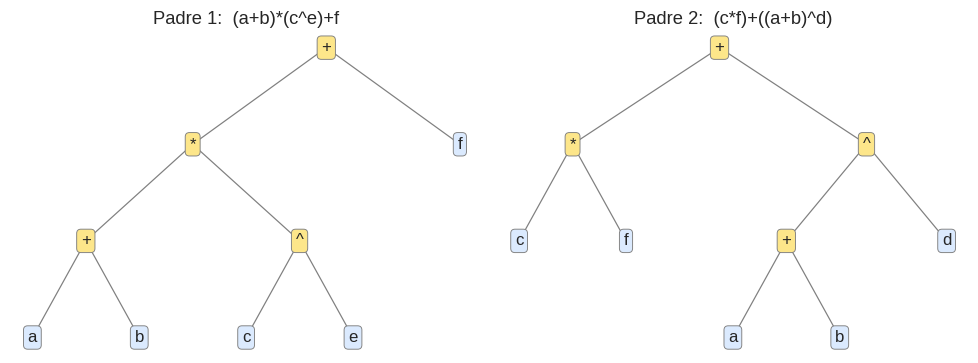

In [ ]:
# ---- Utilidades para leer y dibujar árboles de DEAP (se reusan en los ejercicios) ----
def a_arbol(ind):
    """Convierte la lista plana en preorden de DEAP en un árbol anidado: (nombre, [hijos]) o un texto para las hojas."""
    def build(i):
        nodo = ind[i]
        if nodo.arity == 0:
            # hoja: si es una acción (función de Python) se usa su nombre; si es variable o constante, su valor
            return (nodo.name if callable(nodo.value) else str(nodo.value)), i + 1
        hijos, j = [], i + 1
        for _ in range(nodo.arity):
            h, j = build(j)
            hijos.append(h)
        return (nodo.name, hijos), j
    return build(0)[0]

def dibujar_arbol(ind, ax, tam=8, simbolos=None):
    """Dibuja el árbol. Amarillo = funciones, azul = terminales. `simbolos` cambia etiquetas (p. ej. 'suma' -> '+')."""
    simbolos = simbolos or {}
    arbol, pos, x = a_arbol(ind), [], [0]
    def layout(n, prof):
        if isinstance(n, str):
            p = (x[0], -prof); x[0] += 1
            pos.append((p, simbolos.get(n, n), [])); return p
        nom, hs = n
        ps = [layout(h, prof + 1) for h in hs]
        p = (np.mean([q[0] for q in ps]), -prof)
        pos.append((p, simbolos.get(nom, nom), ps)); return p
    layout(arbol, 0)
    for p, nom, hijos in pos:
        for q in hijos:
            ax.plot([p[0], q[0]], [p[1], q[1]], color="gray", lw=0.8, zorder=1)
    for p, nom, hijos in pos:
        ax.text(p[0], p[1], nom, ha="center", va="center", fontsize=tam, zorder=2,
                bbox=dict(boxstyle="round,pad=0.25", fc="#dbeafe" if not hijos else "#fde68a", ec="gray", lw=0.6))
    ax.axis("off")

# ---- Ejemplo pequeño: funciones suma, mult, pot; terminales a..f ----
pset_demo = gp.PrimitiveSet("DEMO", 6)
pset_demo.renameArguments(ARG0="a", ARG1="b", ARG2="c", ARG3="d", ARG4="e", ARG5="f")
pset_demo.addPrimitive(operator.add, 2, name="suma")
pset_demo.addPrimitive(operator.mul, 2, name="mult")
pset_demo.addPrimitive(operator.pow, 2, name="pot")
SIMB = {"suma": "+", "mult": "*", "pot": "^"}       # solo para que el dibujo se parezca al de la guía

padre1 = gp.PrimitiveTree.from_string("suma(mult(suma(a, b), pot(c, e)), f)", pset_demo)   # (a+b)*(c^e)+f
padre2 = gp.PrimitiveTree.from_string("suma(mult(c, f), pot(suma(a, b), d))", pset_demo)   # (c*f)+((a+b)^d)

def etiqueta(n):
    # los terminales renombrados guardan su nombre en .value; las funciones, en .name
    return n.name if n.arity > 0 else str(n.value)

print("Padre 1 en preorden:", [etiqueta(n) for n in padre1])
f1 = gp.compile(padre1, pset_demo)
print("Evaluado con a=1, b=2, c=2, d=3, e=3, f=1  ->", f1(1, 2, 2, 3, 3, 1), " (esperado: (1+2)*(2^3)+1 = 25)")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
dibujar_arbol(padre1, axes[0], tam=11, simbolos=SIMB); axes[0].set_title("Padre 1:  (a+b)*(c^e)+f")
dibujar_arbol(padre2, axes[1], tam=11, simbolos=SIMB); axes[1].set_title("Padre 2:  (c*f)+((a+b)^d)")
plt.tight_layout(); plt.show()

Un árbol **es** el programa: para "ejecutarlo" se evalúa desde las hojas hacia arriba. Con los valores de prueba, el padre 1 da 25.

### 1.2 Cruce: intercambiar subárboles

Se elige un punto de cruce en cada padre y se intercambian los subárboles que cuelgan de ahí. Con el ejemplo de la guía: en el padre 1 se toma el subárbol `c^e` y en el padre 2 la hoja `b`. Como se cambian subárboles completos, **los hijos siempre son programas válidos**.

Hijo 1: suma(mult(suma(a, b), b), f)
Hijo 2: suma(mult(c, f), pot(suma(a, pot(c, e)), d))


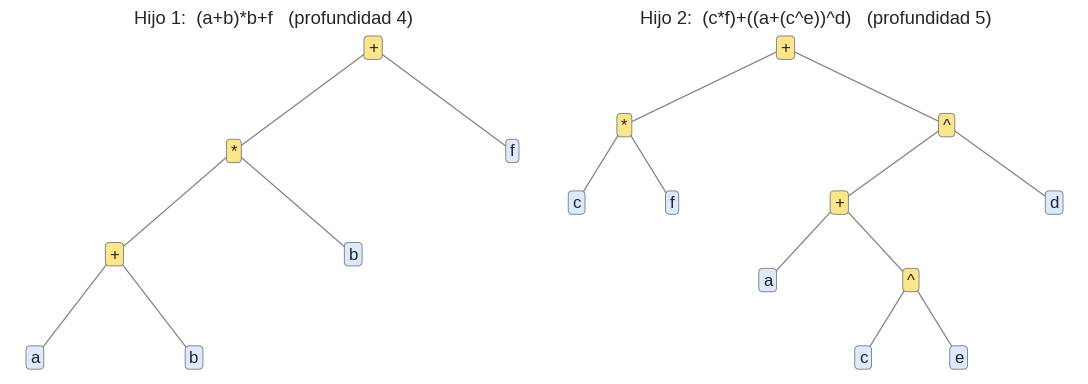

In [ ]:
# Punto de cruce 1: el nodo 'pot' (c^e) del padre 1.  Punto de cruce 2: la hoja 'b' del padre 2.
i1 = [etiqueta(n) for n in padre1].index("pot")
i2 = [etiqueta(n) for n in padre2].index("b")
s1, s2 = padre1.searchSubtree(i1), padre2.searchSubtree(i2)     # rangos de la lista que forman cada subárbol

hijo1, hijo2 = copy.deepcopy(padre1), copy.deepcopy(padre2)
sub1, sub2 = padre1[s1], padre2[s2]                              # los dos fragmentos
hijo1[s1] = sub2                                                 # el hijo 1 recibe 'b' donde estaba c^e
hijo2[s2] = sub1                                                 # el hijo 2 recibe c^e donde estaba 'b'

print("Hijo 1:", hijo1)
print("Hijo 2:", hijo2)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
dibujar_arbol(hijo1, axes[0], tam=11, simbolos=SIMB); axes[0].set_title("Hijo 1:  (a+b)*b+f   (profundidad 4)")
dibujar_arbol(hijo2, axes[1], tam=11, simbolos=SIMB); axes[1].set_title("Hijo 2:  (c*f)+((a+(c^e))^d)   (profundidad 5)")
plt.tight_layout(); plt.show()

Son los mismos hijos de la figura 4.4 de la guía. Fíjate que el hijo 2 quedó más profundo que sus padres (5 contra 4). Si esto se repite generación tras generación, los árboles crecen sin control, y por eso los ejercicios limitan la altura máxima.

### 1.3 Mutación

La mutación toma un nodo al azar y reemplaza todo el subárbol que cuelga de él por uno nuevo generado al azar. Es el operador que agrega variedad nueva (el cruce solo recombina lo que ya existe). En los ejercicios se usa `gp.mutUniform`, que hace justo esto.

In [ ]:
random.seed(3)
mutante, = gp.mutUniform(copy.deepcopy(padre1), expr=partial(gp.genFull, pset=pset_demo, min_=0, max_=1), pset=pset_demo)
# (genFull con altura 0..1 genera un subárbol pequeño)
print("Antes:  ", padre1)
print("Después:", mutante)

Antes:   suma(mult(suma(a, b), pot(c, e)), f)
Después: suma(mult(suma(c, b), pot(c, e)), f)


Acá la mutación cayó en la hoja `a` y la cambió por `c`. Según el nodo que salga sorteado, el cambio puede ir desde una hoja hasta medio árbol.

### 1.4 Cómo se corresponde el ciclo con DEAP

| En la guía | En este notebook |
|---|---|
| Población inicial aleatoria | `gp.genHalfAndHalf` (mezcla árboles "completos" y "irregulares" de altura 1 a 3 o 4) |
| Selección proporcional a la aptitud | `tools.selTournament` (torneo): se sortean 5 individuos y el mejor pasa a ser padre |
| Cruce | `gp.cxOnePoint` (un punto de cruce aleatorio en cada padre; nunca la raíz) |
| Mutación | `gp.mutUniform` |
| Límite al crecimiento | `gp.staticLimit` sobre la altura del árbol: si un hijo se pasa, se queda con el padre |
| Ciclo evolutivo | `algorithms.eaSimple` |
| "El mejor hasta ahora" | `tools.HallOfFame` |

Dos detalles de `eaSimple` que difieren un poco del texto de la guía:

- En cada generación, cada pareja se cruza con probabilidad `cxpb` y luego cada individuo se muta con probabilidad `mutpb`. No son tres operaciones excluyentes (reproducir, cruzar o mutar): un individuo puede pasar sin cambios, cruzarse, mutar o las dos cosas.
- No hay elitismo dentro de la población: la nueva generación reemplaza a la anterior. El `HallOfFame` guarda el mejor individuo de **todas** las generaciones, que es lo que la guía llama "el mejor hasta ahora" y lo que se entrega como resultado.

## 2. Ejercicio 2: robot repartidor de galletas

**Enunciado.** Un robot le entrega galletas al grupo de ingenieros de diseño de robots. Cada vez que un ingeniero recibe una galleta gana puntos. Los ingenieros están distribuidos en una sala cuadrada. Hay que programar por PG el recorrido del robot, definiendo el conjunto de terminales, el de funciones y la función de aptitud.

### 2.1 Cómo se modela el problema


- **Sala:** cuadrícula de 10 × 10 celdas con 15 ingenieros en celdas distintas, sorteadas al azar.
- **Robot:** sale de la puerta (esquina superior izquierda) mirando al este. Tiene 150 acciones de energía; avanzar, girar a la izquierda y girar a la derecha cuestan 1 cada una.
- **Entrega:** si el robot entra a la celda de un ingeniero, le entrega la galleta y gana 1 punto. Cada ingeniero recibe máximo una.
- **Sensores:** solo ve la celda de adelante: ¿hay un ingeniero? y ¿hay una pared?
- **Ejecución:** el programa evolucionado se repite en ciclo hasta que se acaba la energía.

Es el clásico problema de la *hormiga artificial* de Koza: el árbol no calcula un número, **ejecuta acciones**.

### 2.2 Pasos preparatorios

| Paso | Definición |
|---|---|
| 1. Problema | Maximizar las galletas entregadas en una sala que el robot no conoce de antemano. |
| 2. Terminales | `avanzar`, `izquierda`, `derecha` (acciones, sin argumentos). |
| 3. Funciones | `prog2(a, b)` y `prog3(a, b, c)`: ejecutan sus argumentos en secuencia. `if_ing(a, b)`: si hay ingeniero adelante hace `a`, si no `b`. `if_pared(a, b)`: igual, pero con la pared. |
| 4. Aptitud | Promedio de galletas entregadas en 10 salas de entrenamiento (máximo 15), menos 0.002 por cada nodo del árbol para frenar el crecimiento inútil. |
| 5. Parámetros | Población 400, 50 generaciones, cruce 0.7 (un punto), mutación 0.2 (subárbol), torneo de tamaño 5, altura máxima 10. |
| 6. Resultado y parada | Se para al completar las generaciones. El resultado es el mejor individuo de la corrida. |

**Clausura.** Todas las funciones reciben acciones y devuelven una acción, y todos los terminales son acciones, así que cualquier subárbol se puede cambiar por cualquier otro.

**Por qué 10 salas de entrenamiento.** Con una sola sala el robot podría memorizar ese recorrido y no servir en otra. Con varias, la aptitud premia comportamientos generales. Al final se prueba en 50 salas que nunca vio.

**Sobre los parámetros.** En el ejemplo de regresión simbólica de la guía se usó mutación 0.01 y 500 generaciones. Acá la mutación es más alta y hay menos generaciones porque cada evaluación es una simulación completa y se quería que corriera en pocos segundos.

### 2.3 La sala, el robot y cómo un árbol "ejecuta acciones"

En la celda siguiente se define el simulador (clase `Robot`) y el conjunto de funciones y terminales. Un detalle de implementación importante: los terminales (`avanzar`, `izquierda`, `derecha`) son **funciones sin llamar**, y cada función del árbol (`prog2`, `if_ing`...) **devuelve otra función**. Así, el árbol completo se compila a una única función que, al llamarla, corre una pasada del programa. El simulador la llama una y otra vez hasta gastar la energía.

In [ ]:
# ---------------- Sala y robot ----------------
N, N_ING, PASOS = 10, 15, 150                # lado de la sala, ingenieros, energía del robot
DIRS = [(0, 1), (1, 0), (0, -1), (-1, 0)]    # este, sur, oeste, norte  (como (fila, columna))

def generar_sala(seed):
    """Devuelve el conjunto de celdas donde hay ingenieros (nunca en la puerta (0,0))."""
    rng = random.Random(seed)
    celdas = [(i, j) for i in range(N) for j in range(N) if (i, j) != (0, 0)]
    return frozenset(rng.sample(celdas, N_ING))

class Robot:
    def __init__(self, ingenieros):
        self.ing = set(ingenieros)           # ingenieros que todavía NO tienen galleta
        self.pos, self.d = (0, 0), 0         # posición y dirección (0 = este)
        self.pasos, self.galletas = 0, 0
        self.ruta = [self.pos]               # para dibujar el recorrido después
    def _frente(self):
        di, dj = DIRS[self.d]
        return (self.pos[0] + di, self.pos[1] + dj)
    def _dentro(self, p):
        return 0 <= p[0] < N and 0 <= p[1] < N
    # --- acciones (cada una cuesta 1 de energía) ---
    def avanzar(self):
        if self.pasos >= PASOS: return
        self.pasos += 1
        f = self._frente()
        if self._dentro(f):                  # si hay pared, se queda quieto (igual gasta la energía)
            self.pos = f; self.ruta.append(f)
            if f in self.ing:                # entra a la celda de un ingeniero: le entrega la galleta
                self.ing.remove(f); self.galletas += 1
    def izquierda(self):
        if self.pasos >= PASOS: return
        self.pasos += 1; self.d = (self.d - 1) % 4
    def derecha(self):
        if self.pasos >= PASOS: return
        self.pasos += 1; self.d = (self.d + 1) % 4
    # --- sensores ---
    def ing_adelante(self):   return self._frente() in self.ing
    def pared_adelante(self): return not self._dentro(self._frente())
    def run(self, rutina):
        """Repite el programa hasta que se acabe la energía o se entreguen todas las galletas."""
        while self.pasos < PASOS and self.galletas < N_ING:
            antes = self.pasos
            rutina()
            if self.pasos == antes: break    # un programa que no gasta energía se cortaría en un ciclo infinito
        return self.galletas

# ---------------- Funciones y terminales de la PG ----------------
robot = None    # se reemplaza en cada simulación; las acciones del árbol actúan sobre este robot

def _secuencia(*acciones):
    for a in acciones: a()
def _condicional(sensor, a, b):
    cond = robot.ing_adelante() if sensor == "ing" else robot.pared_adelante()
    (a if cond else b)()

# Cada función del árbol recibe funciones y devuelve otra función (con partial)
def prog2(a, b):     return partial(_secuencia, a, b)
def prog3(a, b, c):  return partial(_secuencia, a, b, c)
def if_ing(a, b):    return partial(_condicional, "ing", a, b)
def if_pared(a, b):  return partial(_condicional, "pared", a, b)

pset = gp.PrimitiveSet("MAIN", 0)            # 0 = el programa no recibe entradas
for f, aridad in [(prog2, 2), (prog3, 3), (if_ing, 2), (if_pared, 2)]:
    pset.addPrimitive(f, aridad)
pset.addTerminal(lambda: robot.avanzar(),   name="avanzar")
pset.addTerminal(lambda: robot.izquierda(), name="izquierda")
pset.addTerminal(lambda: robot.derecha(),   name="derecha")
print("Terminales:", [t.name for t in pset.terminals[object]])
print("Funciones: ", [f"{p.name}/{p.arity}" for p in pset.primitives[object]])

Terminales: ['avanzar', 'izquierda', 'derecha']
Funciones:  ['prog2/2', 'prog3/3', 'if_ing/2', 'if_pared/2']


### 2.4 Configuración de la evolución (toolbox de DEAP)

Aquí se registran los operadores (población inicial, selección, cruce, mutación) y la **función de aptitud**. La aptitud corre el árbol en las 10 salas de entrenamiento y devuelve el promedio de galletas menos la penalización por tamaño. Las 50 salas de prueba solo se usan al final.

In [ ]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))                    # queremos maximizar
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)    # un individuo es un árbol con aptitud

tb = base.Toolbox()
tb.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)             # árboles iniciales de altura 1 a 3
tb.register("individual", tools.initIterate, creator.Individual, tb.expr)
tb.register("population", tools.initRepeat, list, tb.individual)
tb.register("compile", gp.compile, pset=pset)                                 # árbol -> función ejecutable

SALAS_TRAIN = [generar_sala(s) for s in range(1, 11)]        # 10 salas para evolucionar
SALAS_TEST  = [generar_sala(s) for s in range(1000, 1050)]   # 50 salas nuevas, solo para evaluar al final

def galletas_por_sala(ind, salas):
    """Corre el programa `ind` en cada sala y devuelve un arreglo con las galletas entregadas en cada una."""
    global robot
    rutina = tb.compile(expr=ind)
    out = []
    for s in salas:
        robot = Robot(s)
        out.append(robot.run(rutina))
    return np.array(out)

def aptitud(ind):
    # galletas promedio en entrenamiento, menos una penalización pequeña por nodo
    return (galletas_por_sala(ind, SALAS_TRAIN).mean() - 0.002 * len(ind),)

tb.register("evaluate", aptitud)
tb.register("select", tools.selTournament, tournsize=5)                       # torneo de 5
tb.register("mate", gp.cxOnePoint)                                            # cruce de un punto
tb.register("expr_mut", gp.genFull, min_=0, max_=2)                           # subárboles nuevos para la mutación
tb.register("mutate", gp.mutUniform, expr=tb.expr_mut, pset=pset)
# límite de altura: si un hijo supera 10 niveles, se descarta y se queda con el padre
tb.decorate("mate",   gp.staticLimit(operator.attrgetter("height"), 10))
tb.decorate("mutate", gp.staticLimit(operator.attrgetter("height"), 10))

### 2.5 Evolución

La PG es estocástica: cada corrida (semilla) puede terminar en un programa distinto. Se corre 5 veces y se guarda el mejor de cada una. La elegida al final es la de mayor aptitud de **entrenamiento**; la prueba no se usa para elegir, solo para medir.

In [ ]:
def evolucionar(seed, pop_size=400, gens=50):
    random.seed(seed); np.random.seed(seed)
    pop = tb.population(n=pop_size)
    hof = tools.HallOfFame(1)                                    # guarda el mejor individuo de todas las generaciones
    stats = tools.Statistics(lambda i: i.fitness.values[0])
    stats.register("max", np.max); stats.register("prom", np.mean)
    pop, log = algorithms.eaSimple(pop, tb, cxpb=0.7, mutpb=0.2, ngen=gens,
                                   stats=stats, halloffame=hof, verbose=False)
    return hof[0], log

corridas = []
for seed in range(5):
    t = time.time()
    mejor, log = evolucionar(seed)
    corridas.append(dict(seed=seed, ind=mejor, log=log,
                         train=galletas_por_sala(mejor, SALAS_TRAIN).mean(),
                         test=galletas_por_sala(mejor, SALAS_TEST).mean(),
                         nodos=len(mejor)))
    print(f"semilla {seed}: entrenamiento {corridas[-1]['train']:.2f} | prueba {corridas[-1]['test']:.2f} | nodos {len(mejor)} | {time.time()-t:.0f} s")

tabla = pd.DataFrame([{k: c[k] for k in ("seed", "train", "test", "nodos")} for c in corridas]).set_index("seed")
tabla.columns = ["Entrenamiento (galletas/15)", "Prueba, 50 salas nuevas (galletas/15)", "Nodos"]
tabla.round(2)

semilla 0: entrenamiento 13.80 | prueba 11.48 | nodos 56 | 13 s


semilla 1: entrenamiento 14.20 | prueba 13.76 | nodos 32 | 13 s


semilla 2: entrenamiento 12.00 | prueba 12.16 | nodos 11 | 10 s


semilla 3: entrenamiento 13.20 | prueba 12.20 | nodos 48 | 13 s


semilla 4: entrenamiento 13.00 | prueba 12.84 | nodos 15 | 11 s


,Entrenamiento (galletas/15),"Prueba, 50 salas nuevas (galletas/15)",Nodos
seed,,,
0,13.8,11.48,56
1,14.2,13.76,32
2,12.0,12.16,11
3,13.2,12.20,48
4,13.0,12.84,15


Se ve el efecto de generalizar: en casi todas las corridas la prueba sale por debajo del entrenamiento, porque los programas se ajustaron un poco a las 10 salas que vieron.

Ahora se elige la corrida con mayor aptitud de entrenamiento y se grafica cómo evolucionó. Las líneas grises son las otras corridas.

Corrida elegida: semilla 1


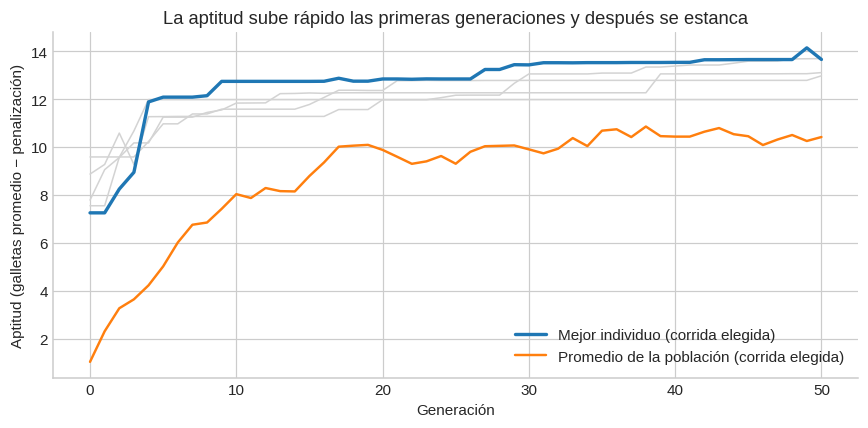

In [ ]:
elegida = max(corridas, key=lambda c: c["train"])
mejor_robot = elegida["ind"]
print("Corrida elegida: semilla", elegida["seed"])

fig, ax = plt.subplots(figsize=(8, 4))
for c in corridas:
    ax.plot(c["log"].select("max"), color="lightgray", lw=1)
ax.plot(elegida["log"].select("max"), color="C0", lw=2.2, label="Mejor individuo (corrida elegida)")
ax.plot(elegida["log"].select("prom"), color="C1", lw=1.6, label="Promedio de la población (corrida elegida)")
ax.set_xlabel("Generación"); ax.set_ylabel("Aptitud (galletas promedio − penalización)")
ax.set_title("La aptitud sube rápido las primeras generaciones y después se estanca")
ax.legend(frameon=False); plt.tight_layout(); guardar(fig, "curva_aptitud_robot"); plt.show()

### 2.6 El programa que evolucionó

El árbol como texto y traducido a pseudocódigo (los `prog2` y `prog3` se vuelven una secuencia de instrucciones), y dibujado.

In [ ]:
def pseudocodigo(ind):
    def fmt(n, s):
        pad = "    " * s
        if isinstance(n, str): return [f"{pad}{n}()"]
        nom, hs = n
        if nom in ("prog2", "prog3"): return sum((fmt(h, s) for h in hs), [])
        cond = "hay ingeniero adelante" if nom == "if_ing" else "hay pared adelante"
        return [f"{pad}si {cond}:"] + fmt(hs[0], s + 1) + [f"{pad}si no:"] + fmt(hs[1], s + 1)
    return "\n".join(["repetir hasta que se acabe la energía:"] + fmt(a_arbol(ind), 1))

print(str(mejor_robot), "\n")
print(pseudocodigo(mejor_robot))

prog3(if_pared(izquierda, avanzar), prog2(prog2(avanzar, avanzar), prog2(avanzar, avanzar)), if_pared(prog2(derecha, prog2(avanzar, if_ing(prog2(avanzar, if_ing(izquierda, derecha)), if_ing(avanzar, derecha)))), prog2(if_pared(if_pared(izquierda, avanzar), izquierda), avanzar))) 

repetir hasta que se acabe la energía:
    si hay pared adelante:
        izquierda()
    si no:
        avanzar()
    avanzar()
    avanzar()
    avanzar()
    avanzar()
    si hay pared adelante:
        derecha()
        avanzar()
        si hay ingeniero adelante:
            avanzar()
            si hay ingeniero adelante:
                izquierda()
            si no:
                derecha()
        si no:
            si hay ingeniero adelante:
                avanzar()
            si no:
                derecha()
    si no:
        si hay pared adelante:
            si hay pared adelante:
                izquierda()
            si no:
                avanzar()
        si no:
            izquierda()
 

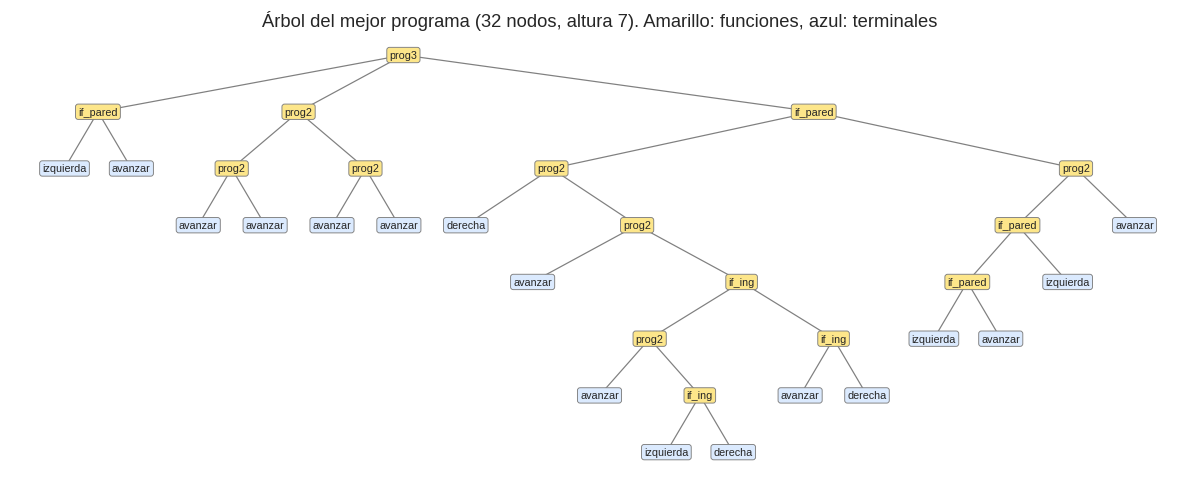

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
dibujar_arbol(mejor_robot, ax, tam=7)
ax.set_title(f"Árbol del mejor programa ({len(mejor_robot)} nodos, altura {mejor_robot.height}). Amarillo: funciones, azul: terminales")
plt.tight_layout(); plt.show()

### 2.7 Cómo se ve en una sala nueva

Recorrido del robot en la primera sala de prueba, junto al de una regla escrita a mano (avanzar y girar a la derecha cuando hay pared). Puntos verdes: ingenieros que recibieron galleta. Equis rojas: los que se quedaron sin ella. La línea azul es el camino.

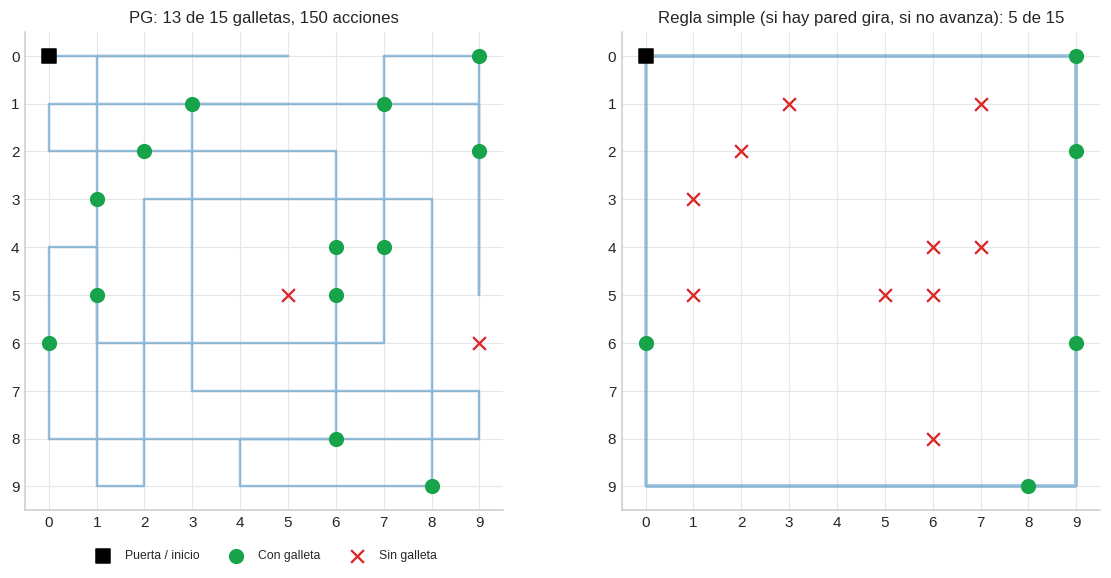

In [ ]:
def dibujar_sala(ax, sala, rutina):
    """Corre `rutina` en `sala` y dibuja el recorrido. Deja el robot usado en la variable global `robot`."""
    global robot
    robot = Robot(sala); robot.run(rutina)
    entregados = set(sala) - robot.ing
    ax.set_xlim(-0.5, N - 0.5); ax.set_ylim(N - 0.5, -0.5); ax.set_aspect("equal")
    ax.set_xticks(range(N)); ax.set_yticks(range(N)); ax.grid(True, color="#e5e7eb")
    r = np.array(robot.ruta)
    ax.plot(r[:, 1], r[:, 0], color="C0", alpha=0.45, lw=1.6, zorder=1)
    ax.scatter(r[0, 1], r[0, 0], marker="s", s=90, color="black", zorder=3, label="Puerta / inicio")
    if entregados:
        e = np.array(list(entregados)); ax.scatter(e[:, 1], e[:, 0], s=80, color="#16a34a", zorder=3, label="Con galleta")
    if robot.ing:
        m = np.array(list(robot.ing)); ax.scatter(m[:, 1], m[:, 0], marker="x", s=70, color="#dc2626", zorder=3, label="Sin galleta")

def regla_pared():
    """Referencia escrita a mano: si hay pared adelante gira a la derecha, si no avanza."""
    if robot.pared_adelante(): robot.derecha()
    else: robot.avanzar()

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
dibujar_sala(axes[0], SALAS_TEST[0], tb.compile(expr=mejor_robot))
axes[0].set_title(f"PG: {robot.galletas} de {N_ING} galletas, {robot.pasos} acciones", fontsize=11)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=3, frameon=False, fontsize=8)
dibujar_sala(axes[1], SALAS_TEST[0], regla_pared)
axes[1].set_title(f"Regla simple (si hay pared gira, si no avanza): {robot.galletas} de {N_ING}", fontsize=11)
plt.tight_layout(); guardar(fig, "ruta_robot"); plt.show()

### 2.8 Comparación en 50 salas que el robot nunca vio

Se compara contra dos referencias: un robot que elige la acción **al azar** y la **regla de la pared** de arriba. Si el robot evolucionado no le gana claramente a esto, la PG no estaría aportando nada.

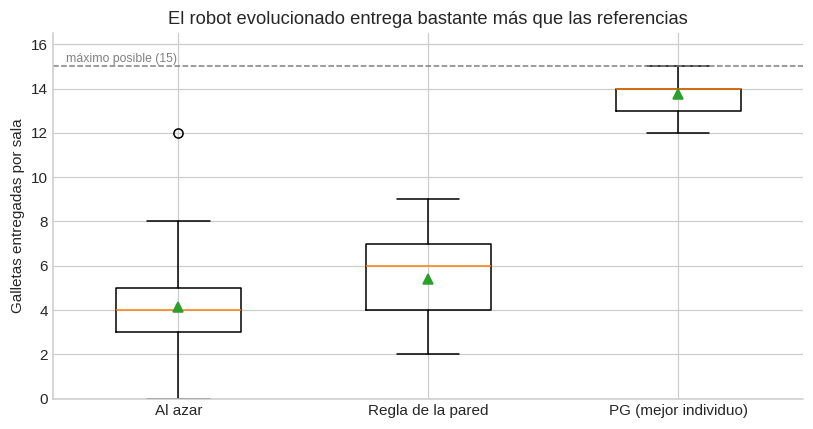

,promedio,desv. estándar,mínimo,máximo
Al azar,4.14,1.95,0.0,12.0
Regla de la pared,5.40,1.88,2.0,9.0
PG (mejor individuo),13.76,0.88,12.0,15.0


In [ ]:
def por_azar(salas, seed=0):
    global robot
    rng = random.Random(seed); out = []
    for s in salas:
        robot = Robot(s)
        while robot.pasos < PASOS:
            rng.choice([robot.avanzar, robot.izquierda, robot.derecha])()
        out.append(robot.galletas)
    return np.array(out)

def por_regla(salas):
    global robot
    out = []
    for s in salas:
        robot = Robot(s)
        while robot.pasos < PASOS: regla_pared()
        out.append(robot.galletas)
    return np.array(out)

res = {"Al azar": por_azar(SALAS_TEST),
       "Regla de la pared": por_regla(SALAS_TEST),
       "PG (mejor individuo)": galletas_por_sala(mejor_robot, SALAS_TEST)}

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.boxplot(list(res.values()), showmeans=True, widths=0.5)
ax.set_xticklabels(list(res.keys()))
ax.axhline(N_ING, color="gray", ls="--", lw=1); ax.text(0.55, N_ING + 0.2, "máximo posible (15)", fontsize=8, color="gray")
ax.set_ylabel("Galletas entregadas por sala"); ax.set_ylim(0, N_ING + 1.5)
ax.set_title("El robot evolucionado entrega bastante más que las referencias")
plt.tight_layout(); guardar(fig, "comparacion_robot"); plt.show()
pd.DataFrame({k: [v.mean(), v.std(), v.min(), v.max()] for k, v in res.items()},
             index=["promedio", "desv. estándar", "mínimo", "máximo"]).T.round(2)

### 2.9 Conclusiones del ejercicio 2


- **Funciona.** El robot evolucionado entrega en promedio **13.8 de 15 galletas** en las 50 salas nuevas (mínimo 12). El robot al azar entrega 4.1 y la regla de "girar si hay pared" 5.4.
- **Ojo con ese número.** Es de la corrida que mejor quedó en entrenamiento. Las 5 corridas promedian 12.5 en prueba (entre 11.5 y 13.8), así que lo razonable es esperar entre 12 y 13 galletas, no 14.
- **Qué hace.** Hace pasadas rectas largas que cruzan la sala y se va acomodando cuando topa con una pared. No es un barrido ordenado, y es normal: no tiene memoria y solo ve la celda de adelante.
- **Código sobrante.** El árbol elegido (32 nodos) trae partes que no aportan, como un `if_pared` dentro de otro `if_pared` o varios `avanzar` seguidos. La penalización por tamaño ayuda pero no lo elimina. La corrida de 11 nodos (semilla 2) llega a 12.2 en prueba, casi lo mismo con una tercera parte del código.
- **Límites.** Todo depende de lo que se asumió: sala de 10 × 10, 15 ingenieros, 150 acciones y la forma de la aptitud. Un barrido perfecto en zigzag (99 avances y unos 18 giros) cabría en las 150 acciones, pero exige alternar el sentido de los giros y el robot no tiene memoria, así que un programa así es difícil de evolucionar con estas funciones. Otro tamaño de sala, más ingenieros o más energía cambian los números.

## 3. Ejercicio 3: detección de fraudes

**Enunciado.** Generar aleatoriamente un archivo con monto en pesos, hora del día, distancia a la residencia, ingreso mensual y fraude sí/no. Revisarlo y hacer cambios para que sea más real. Encontrar un modelo que determine un posible fraude.

Se hace en tres pasos: primero el archivo ingenuo (todo al azar), luego la revisión con los cambios, y al final el modelo por PG.

### 3.1 Primer archivo: todo al azar

Lo más literal del enunciado es sortear cada columna con una distribución uniforme y la etiqueta con una moneda. La celda de abajo lo genera y revisa qué tan real se ve, y si un modelo fuerte (gradient boosting) puede aprender algo de él.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

def version1(n=20000, seed=42):
    """Versión ingenua: todo uniforme e independiente, y el fraude es una moneda."""
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        "monto": rng.integers(1_000, 5_000_000, n),
        "hora": rng.integers(0, 24, n),
        "distancia_km": rng.uniform(0, 500, n).round(1),
        "ingreso_mensual": rng.integers(1_000_000, 15_000_000, n),
        "fraude": rng.integers(0, 2, n),
    })

v1 = version1()
print(v1.head(), "\n")
print("Tasa de fraude:", f"{v1.fraude.mean():.1%}")
print("Transacciones con monto mayor al ingreso mensual completo:", f"{(v1.monto > v1.ingreso_mensual).mean():.1%}")
print("Distancia media al domicilio:", f"{v1.distancia_km.mean():.0f} km")
X1 = v1.drop(columns="fraude")
auc_v1 = cross_val_score(GradientBoostingClassifier(random_state=0), X1, v1.fraude, cv=3, scoring="roc_auc").mean()
print(f"AUC de un modelo fuerte (gradient boosting, validación cruzada): {auc_v1:.3f}  (0.5 = no aprende nada)")

     monto  hora  distancia_km  ingreso_mensual  fraude
0   447165     4         122.5          1573682       0
1  3870006    11         298.9         14299029       0
2  3273203     0         207.6          1130808       0
3  2194953    16         318.8          6441979       1
4  2165643     7         293.2         14696988       1 

Tasa de fraude: 50.2%
Transacciones con monto mayor al ingreso mensual completo: 11.4%
Distancia media al domicilio: 251 km


AUC de un modelo fuerte (gradient boosting, validación cruzada): 0.501  (0.5 = no aprende nada)


### 3.2 Revisión: qué está mal y qué se cambió

El AUC da ~0.5: en este archivo la etiqueta no depende de ninguna columna, así que **no hay nada que aprender**. Además, los datos no se parecen a transacciones reales. Los cambios de la versión 2:

| Problema del primer archivo | Cambio en la versión 2 |
|---|---|
| La mitad de las transacciones son fraude | El fraude es raro, ~3%. El desbalance es lo normal en este problema y cambia cómo se mide el modelo. |
| Ingreso y monto independientes; hay compras mayores al sueldo de todo el mes | El monto se genera como **fracción del ingreso** (lognormal), con mediana ~2.5% del ingreso. |
| Ingresos uniformes entre 1 y 15 millones | Ingreso **lognormal** con mediana ~2.8 millones: mucha gente abajo y cola larga arriba. |
| Hora uniforme (igual de probable comprar a las 3 a.m. que a las 2 p.m.) | Compras concentradas en la mañana, la tarde y la noche temprana; muy pocas en la madrugada (~4%). |
| Distancia uniforme hasta 500 km | La mayoría de las compras son cerca de casa (exponencial), algunas en otra zona de la ciudad y un ~5% de viajes lejanos que **son legítimos**. |
| La etiqueta no depende de nada | Los fraudes tienen otro perfil: monto mediano de ~10% del ingreso (contra ~2.5%), ~39% en la madrugada (contra ~4%) y ~45% a más de 40 km de casa (contra ~5%). |
| Fraudes perfectamente distinguibles | ~15% de los fraudes se ven completamente normales y ~0.2% de las etiquetas están mal. Así queda un error que ningún modelo puede quitar. |

Todos esos porcentajes son parámetros elegidos a mano; no vienen de datos reales, así que lo que el modelo "descubra" es lo que se puso en el generador. Las cifras de la tabla se verifican al imprimir la versión 2.

In [ ]:
def version2(n=20000, tasa_fraude=0.03, seed=42):
    """Versión revisada: distribuciones realistas, fraude raro y con perfil propio, y algo de ruido."""
    rng = np.random.default_rng(seed)
    fraude = (rng.random(n) < tasa_fraude).astype(int)
    f = fraude == 1

    # Ingreso mensual (COP): lognormal, sesgado a la derecha, entre 1.1 y 30 millones
    ingreso = np.clip(rng.lognormal(np.log(2_800_000), 0.6, n), 1_100_000, 30_000_000)

    # Monto como fracción del ingreso; en los fraudes esa fracción es mayor
    frac = np.where(f, rng.lognormal(np.log(0.12), 0.8, n), rng.lognormal(np.log(0.025), 0.9, n))
    monto = np.clip(ingreso * frac, 2_000, None)

    # Hora: mezcla de mañana (10), tarde (14) y noche temprana (19.5); los fraudes tienen más peso en la madrugada
    def hora_normal(k):
        comp = rng.choice(3, k, p=[0.30, 0.40, 0.30])
        h = np.where(comp == 0, rng.normal(10, 2, k), np.where(comp == 1, rng.normal(14, 2.5, k), rng.normal(19.5, 2, k)))
        return np.mod(np.round(h), 24).astype(int)
    hora = hora_normal(n)
    madrugada = rng.random(n) < np.where(f, 0.45, 0.03)
    hora = np.where(madrugada, rng.integers(0, 6, n), hora)

    # Distancia al domicilio (km): 68% local, 27% otra zona de la ciudad, 5% viaje lejano (legítimo)
    tipo = rng.choice(3, n, p=[0.68, 0.27, 0.05])
    dist = np.where(tipo == 0, rng.exponential(3.5, n), np.where(tipo == 1, rng.gamma(4, 4, n), rng.uniform(60, 900, n)))
    lejos = rng.random(n) < np.where(f, 0.50, 0.0)          # la mitad de los fraudes ocurre lejos
    dist = np.where(lejos, rng.uniform(40, 1200, n), dist)

    # 15% de los fraudes "sutiles": monto, hora y distancia de una compra normal
    sutil = f & (rng.random(n) < 0.15)
    monto = np.where(sutil, np.clip(ingreso * rng.lognormal(np.log(0.025), 0.9, n), 2_000, None), monto)
    hora = np.where(sutil, hora_normal(n), hora)
    dist = np.where(sutil, rng.exponential(3.5, n), dist)

    # Ruido en la etiqueta: 0.2% de las transacciones quedan mal clasificadas
    fraude = np.where(rng.random(n) < 0.002, 1 - fraude, fraude)

    return pd.DataFrame({
        "monto": (np.round(monto / 100) * 100).astype(int),
        "hora": hora,
        "distancia_km": np.round(dist, 1),
        "ingreso_mensual": (np.round(ingreso / 10_000) * 10_000).astype(int),
        "fraude": fraude,
    })

df = version2()
df.to_csv("data/fraude_transacciones.csv", index=False)
v1.to_csv("data/fraude_transacciones_v1_ingenuo.csv", index=False)     # se guarda también el primer intento
print(df.shape, "| tasa de fraude:", f"{df.fraude.mean():.2%}", "| fraudes:", df.fraude.sum())
print("Monto mayor al ingreso mensual:", f"{(df.monto > df.ingreso_mensual).mean():.2%}")
fr, lg = df[df.fraude == 1], df[df.fraude == 0]
r = df.monto / df.ingreso_mensual
print(f"Monto/ingreso, mediana: fraude {r[df.fraude==1].median():.1%} | legítima {r[df.fraude==0].median():.1%}")
print(f"Madrugada (hora < 6): fraude {(fr.hora < 6).mean():.0%} | legítima {(lg.hora < 6).mean():.0%}")
print(f"Más de 40 km de casa: fraude {(fr.distancia_km > 40).mean():.0%} | legítima {(lg.distancia_km > 40).mean():.0%}")
df.head(8)

(20000, 5) | tasa de fraude: 3.16% | fraudes: 631
Monto mayor al ingreso mensual: 0.01%
Monto/ingreso, mediana: fraude 10.2% | legítima 2.5%
Madrugada (hora < 6): fraude 39% | legítima 4%
Más de 40 km de casa: fraude 45% | legítima 5%


,monto,hora,distancia_km,ingreso_mensual,fraude
0,21800,14,5.2,1100000,0
1,52400,12,1.5,2210000,0
2,137500,20,21.0,1100000,0
3,570600,13,0.1,9530000,0
4,57700,20,0.2,3180000,0
5,47300,15,1.0,3020000,0
6,43900,13,149.2,3220000,0
7,36600,14,5.7,4020000,0


Cómo se ve el archivo revisado. Arriba a la izquierda, los fraudes (rojo) tienen montos más grandes frente al ingreso, pero las dos distribuciones se **traslapan**: por eso no hay una regla perfecta. Arriba a la derecha, la tasa de fraude se dispara en la madrugada. Abajo a la izquierda, sube con la distancia, aunque también hay compras legítimas lejos.

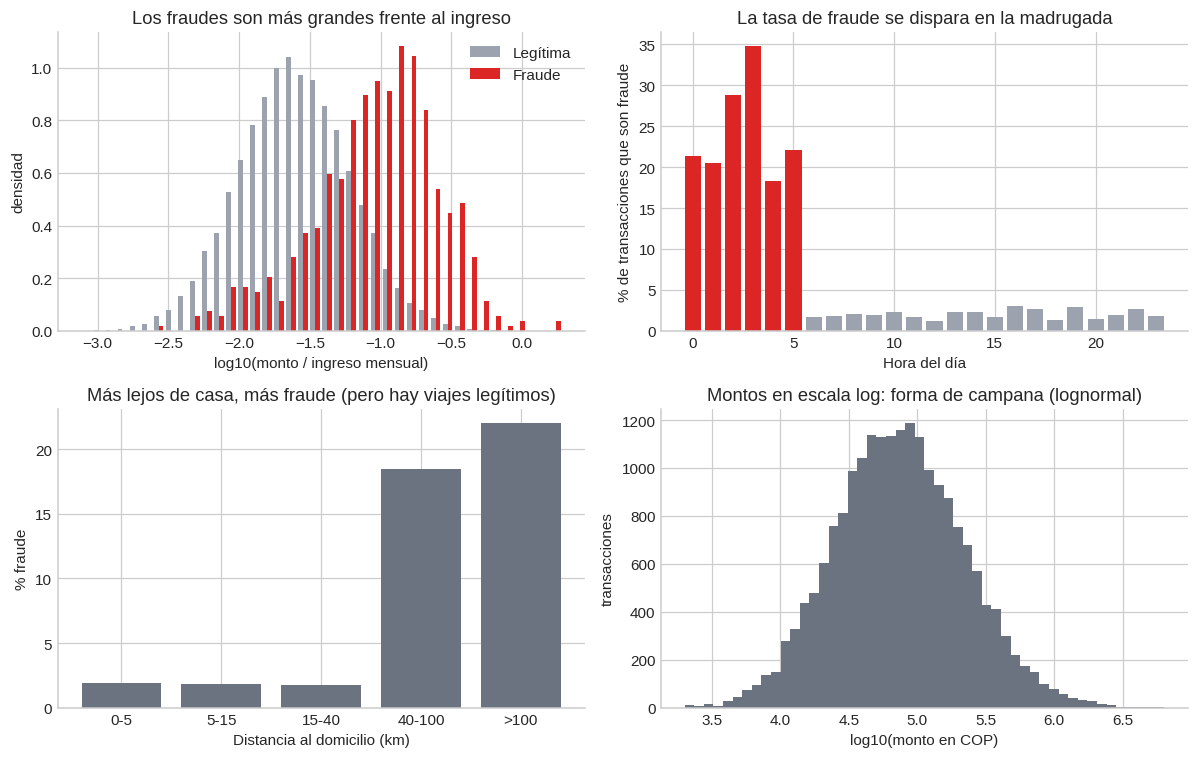

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

ratio = np.log10(df.monto / df.ingreso_mensual)
axes[0, 0].hist([ratio[df.fraude == 0], ratio[df.fraude == 1]], bins=40, density=True, label=["Legítima", "Fraude"], color=["#9ca3af", "#dc2626"])
axes[0, 0].set_xlabel("log10(monto / ingreso mensual)"); axes[0, 0].set_ylabel("densidad")
axes[0, 0].set_title("Los fraudes son más grandes frente al ingreso"); axes[0, 0].legend(frameon=False)

tasa_hora = df.groupby("hora").fraude.mean() * 100
axes[0, 1].bar(tasa_hora.index, tasa_hora.values, color=["#dc2626" if h < 6 else "#9ca3af" for h in tasa_hora.index])
axes[0, 1].set_xlabel("Hora del día"); axes[0, 1].set_ylabel("% de transacciones que son fraude")
axes[0, 1].set_title("La tasa de fraude se dispara en la madrugada")

bins, etq = [0, 5, 15, 40, 100, 2000], ["0-5", "5-15", "15-40", "40-100", ">100"]
tasa_dist = df.groupby(pd.cut(df.distancia_km, bins, labels=etq), observed=True).fraude.mean() * 100
axes[1, 0].bar(tasa_dist.index.astype(str), tasa_dist.values, color="#6b7280")
axes[1, 0].set_xlabel("Distancia al domicilio (km)"); axes[1, 0].set_ylabel("% fraude")
axes[1, 0].set_title("Más lejos de casa, más fraude (pero hay viajes legítimos)")

axes[1, 1].hist(np.log10(df.monto), bins=50, color="#6b7280")
axes[1, 1].set_xlabel("log10(monto en COP)"); axes[1, 1].set_ylabel("transacciones")
axes[1, 1].set_title("Montos en escala log: forma de campana (lognormal)")
plt.tight_layout(); guardar(fig, "datos_fraude"); plt.show()

### 3.3 El modelo por PG: pasos preparatorios

| Paso | Definición |
|---|---|
| 1. Problema | Clasificación binaria: dada una transacción, decidir si es fraude. |
| 2. Terminales | `monto` (millones de COP), `ingreso` (millones de COP), `dist` (cientos de km), `hora_cos` y constantes aleatorias en [−2, 2]. |
| 3. Funciones | `sum`, `res`, `mul`, `div` (protegida: si el denominador es casi 0, devuelve 1), `max`, `min`, `log` (del valor absoluto más 0.001) y `sqrt` (de la raíz del valor absoluto). Todas reciben y devuelven reales, así que hay clausura. |
| 4. Aptitud | **F1 en el conjunto de entrenamiento** menos 0.0005 por nodo. El árbol devuelve un número y se predice *fraude* si es mayor que 0. |
| 5. Parámetros | Población 400, 60 generaciones, cruce 0.7 (un punto), mutación 0.2 (subárbol), torneo de 5, altura máxima 8. |
| 6. Resultado y parada | Fin al completar las generaciones. De los 5 mejores de cada corrida se toma el de mayor F1 en **validación**. |

**Decisiones que vale la pena explicar**

- **`hora_cos = cos(2π·hora/24)`.** La hora es circular: las 23 y las 0 están pegadas. Con la hora cruda, un árbol simple no puede expresar "madrugada" sin varias comparaciones. Con el coseno, la medianoche vale 1 y el mediodía −1. Es la única variable construida a mano.
- **Sin el ratio monto/ingreso.** No se le da al modelo. La PG tendría que descubrir sola que conviene dividir esas dos variables.
- **Escalas.** Las variables se dividen por una constante (millones, cientos de km) para que las constantes aleatorias de [−2, 2] tengan un tamaño razonable frente a ellas.
- **Por qué F1 y no exactitud.** Con 3% de fraude, un modelo que diga siempre "no hay fraude" acierta 97% y no sirve. En una prueba aparte (no incluida acá) con la exactitud balanceada como aptitud, el modelo marcaba demasiadas compras como fraude (recall ~0.78 pero precisión ~0.15), y F1 dio un mejor equilibrio.
- **Tres conjuntos.** 60% entrenamiento (donde evoluciona), 20% validación (para elegir el mejor individuo) y 20% prueba (solo se mira al final). Los tres estratificados por fraude, es decir, con la misma proporción de fraudes.

Las métricas que se usan:

| Métrica | Pregunta que responde |
|---|---|
| Precisión | De lo que el modelo marcó como fraude, ¿cuánto lo era? |
| Recall | De los fraudes reales, ¿cuántos atrapó? |
| F1 | Promedio armónico de las dos: $F_1 = \frac{2\,VP}{2\,VP + FP + FN}$ |
| AUC | ¿Qué tan bien ordena las transacciones, sin importar el umbral? (0.5 = azar, 1 = perfecto) |

In [ ]:
# ---- Variables (terminales) y partición en entrenamiento / validación / prueba ----
df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)
X = pd.DataFrame({"monto": df.monto / 1e6, "ingreso": df.ingreso_mensual / 1e6,
                  "dist": df.distancia_km / 100, "hora_cos": df.hora_cos})
y = df.fraude.values
Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=1)
Xva, Xte, yva, yte = train_test_split(Xtmp, ytmp, test_size=0.5, stratify=ytmp, random_state=1)
print(f"Filas: entrenamiento {len(Xtr)}, validación {len(Xva)}, prueba {len(Xte)}")
print(f"Fraudes: {ytr.sum()}, {yva.sum()}, {yte.sum()}")

# ---- Funciones protegidas: nunca deben producir errores ni infinitos (propiedad de clausura) ----
def pdiv(a, b):
    b = np.asarray(b, dtype=float)
    ok = np.abs(b) > 1e-3
    return np.where(ok, a / np.where(ok, b, 1), 1.0)     # si el denominador es ~0, devuelve 1
def plog(a):  return np.log(np.abs(a) + 1e-3)
def psqrt(a): return np.sqrt(np.abs(a))
def _erc():   return round(random.uniform(-2, 2), 2)     # constante aleatoria efímera

# ---- Conjunto de funciones y terminales ----
nombres = list(X.columns)
pset3 = gp.PrimitiveSet("FRAUDE", len(nombres))          # el árbol recibe 4 entradas: las columnas de X
pset3.renameArguments(**{f"ARG{i}": n for i, n in enumerate(nombres)})
for f, ar, nom in [(np.add, 2, "sum"), (np.subtract, 2, "res"), (np.multiply, 2, "mul"), (pdiv, 2, "div"),
                   (np.maximum, 2, "max"), (np.minimum, 2, "min"), (plog, 1, "log"), (psqrt, 1, "sqrt")]:
    pset3.addPrimitive(f, ar, name=nom)
pset3.addEphemeralConstant("cte", _erc)

# ---- Toolbox ----
creator.create("FMax3", base.Fitness, weights=(1.0,))
creator.create("Ind3", gp.PrimitiveTree, fitness=creator.FMax3)
tb3 = base.Toolbox()
tb3.register("expr", gp.genHalfAndHalf, pset=pset3, min_=1, max_=4)
tb3.register("individual", tools.initIterate, creator.Ind3, tb3.expr)
tb3.register("population", tools.initRepeat, list, tb3.individual)
tb3.register("compile", gp.compile, pset=pset3)

def salida(ind, Xd):
    """Evalúa el árbol sobre todas las filas a la vez (vectorizado) y devuelve un puntaje por transacción."""
    f = tb3.compile(expr=ind)
    out = f(*[Xd[c].values for c in nombres])
    return np.broadcast_to(np.asarray(out, dtype=float), (len(Xd),))     # si el árbol es una constante, se replica

def f1_ind(ind, Xd, yd):
    out = salida(ind, Xd)
    if not np.all(np.isfinite(out)): return 0.0
    p = out > 0                                           # regla de decisión: puntaje > 0  ->  fraude
    tp = (p & (yd == 1)).sum(); fp = (p & (yd == 0)).sum(); fn = (~p & (yd == 1)).sum()
    den = 2 * tp + fp + fn
    return 2 * tp / den if den else 0.0

tb3.register("evaluate", lambda ind: (f1_ind(ind, Xtr, ytr) - 0.0005 * len(ind),))
tb3.register("select", tools.selTournament, tournsize=5)
tb3.register("mate", gp.cxOnePoint)
tb3.register("expr_mut", gp.genFull, min_=0, max_=2)
tb3.register("mutate", gp.mutUniform, expr=tb3.expr_mut, pset=pset3)
tb3.decorate("mate",   gp.staticLimit(operator.attrgetter("height"), 8))
tb3.decorate("mutate", gp.staticLimit(operator.attrgetter("height"), 8))

Filas: entrenamiento 12000, validación 4000, prueba 4000
Fraudes: 379, 126, 126


### 3.4 Evolución

Igual que en el ejercicio 2: 5 corridas con semillas distintas. En cada una se guardan los 5 mejores individuos vistos, y de ellos se toma el que tenga mayor F1 en **validación**. Así la elección no usa el conjunto de prueba. Se reportan las métricas de prueba de cada corrida para ver cuánto varía el resultado entre semillas.

In [ ]:
def evolucionar3(seed, pop_size=400, gens=60):
    random.seed(seed); np.random.seed(seed)
    pop = tb3.population(n=pop_size)
    hof = tools.HallOfFame(5)
    stats = tools.Statistics(lambda i: i.fitness.values[0])
    stats.register("max", np.max); stats.register("prom", np.mean)
    pop, log = algorithms.eaSimple(pop, tb3, 0.7, 0.2, gens, stats=stats, halloffame=hof, verbose=False)
    return max(hof, key=lambda i: f1_ind(i, Xva, yva)), log      # el mejor de los 5 según validación

def metricas(y_real, score, umbral):
    p = score > umbral
    return dict(AUC=roc_auc_score(y_real, score), Precisión=precision_score(y_real, p, zero_division=0),
                Recall=recall_score(y_real, p), F1=f1_score(y_real, p))

corridas3 = []
for seed in range(5):
    t = time.time()
    ind, log = evolucionar3(seed)
    m = metricas(yte, salida(ind, Xte), 0)
    corridas3.append(dict(seed=seed, ind=ind, log=log, f1_val=f1_ind(ind, Xva, yva), nodos=len(ind), **m))
    print(f"semilla {seed}: F1 validación {corridas3[-1]['f1_val']:.3f} | F1 prueba {m['F1']:.3f} | nodos {len(ind)} | {time.time()-t:.0f} s")

pd.DataFrame([{k: c[k] for k in ("seed", "f1_val", "AUC", "Precisión", "Recall", "F1", "nodos")} for c in corridas3]).set_index("seed").round(3)

semilla 0: F1 validación 0.442 | F1 prueba 0.564 | nodos 22 | 9 s


semilla 1: F1 validación 0.443 | F1 prueba 0.541 | nodos 18 | 6 s


semilla 2: F1 validación 0.441 | F1 prueba 0.559 | nodos 28 | 8 s


semilla 3: F1 validación 0.451 | F1 prueba 0.549 | nodos 28 | 7 s


semilla 4: F1 validación 0.429 | F1 prueba 0.526 | nodos 26 | 8 s


,f1_val,AUC,Precisión,Recall,F1,nodos
seed,,,,,,
0,0.442,0.854,0.660,0.492,0.564,22
1,0.443,0.861,0.526,0.556,0.541,18
2,0.441,0.859,0.646,0.492,0.559,28
3,0.451,0.831,0.543,0.556,0.549,28
4,0.429,0.808,0.644,0.444,0.526,26


Las cinco corridas quedan parecidas (F1 de prueba entre 0.53 y 0.56). Se elige la de mayor F1 en validación y se muestra el modelo.

**Cómo leer la expresión:** el árbol es una fórmula que da un puntaje por transacción; si el puntaje es mayor que 0, se marca como fraude. Es correcta pero difícil de leer a ojo, con repeticiones y partes que casi no aportan (típico de la PG sin simplificar). Para saber qué variables pesan de verdad se usa la importancia por permutación, más abajo.

Corrida elegida: semilla 3 | nodos: 28 | altura: 8

Modelo evolucionado (fraude si el resultado es > 0):

sum(sum(sum(mul(monto, dist), min(dist, sum(sum(sum(mul(dist, monto), mul(monto, dist)), res(hora_cos, monto)), div(hora_cos, dist)))), div(hora_cos, 1.49)), log(monto))


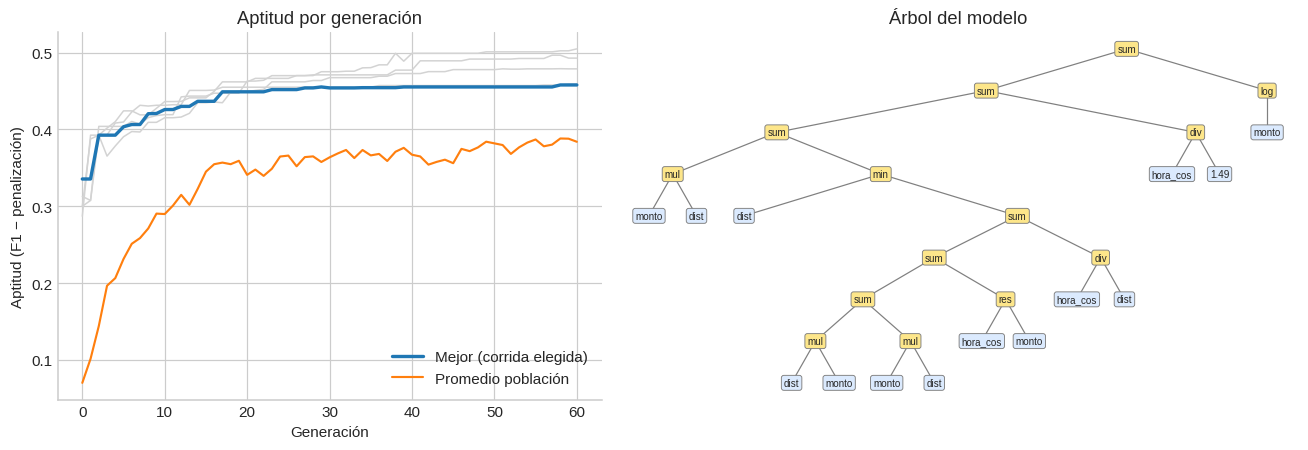

In [ ]:
elegida3 = max(corridas3, key=lambda c: c["f1_val"])      # se elige por validación, no por prueba
mejor_fraude = elegida3["ind"]
print("Corrida elegida: semilla", elegida3["seed"], "| nodos:", len(mejor_fraude), "| altura:", mejor_fraude.height)
print("\nModelo evolucionado (fraude si el resultado es > 0):\n")
print(str(mejor_fraude))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.25]})
for c in corridas3: axes[0].plot(c["log"].select("max"), color="lightgray", lw=1)
axes[0].plot(elegida3["log"].select("max"), color="C0", lw=2.2, label="Mejor (corrida elegida)")
axes[0].plot(elegida3["log"].select("prom"), color="C1", lw=1.4, label="Promedio población")
axes[0].set_xlabel("Generación"); axes[0].set_ylabel("Aptitud (F1 − penalización)"); axes[0].legend(frameon=False)
axes[0].set_title("Aptitud por generación")
dibujar_arbol(mejor_fraude, axes[1], tam=6.5)
axes[1].set_title("Árbol del modelo")
plt.tight_layout(); guardar(fig, "arbol_y_aptitud_fraude"); plt.show()

### 3.5 Resultados en el conjunto de prueba

Se compara el modelo de PG contra tres modelos clásicos con las **mismas cuatro variables** (a ninguno se le da el ratio monto/ingreso). A los clásicos se les ajusta el umbral de decisión para maximizar F1 en validación, lo que les da ventaja: el árbol de PG usa su umbral en 0, sin ajuste posterior. Gradient boosting sirve como techo de referencia de lo que se puede sacar de estos datos.

In [ ]:
def mejor_umbral(score_va, y_va):
    """Umbral que maximiza F1 en validación (solo para los modelos clásicos)."""
    cand = np.quantile(score_va, np.linspace(0.80, 0.999, 200))
    return cand[np.argmax([f1_score(y_va, score_va > u) for u in cand])]

def evaluar_sklearn(nombre, modelo, score_fn):
    modelo.fit(Xtr, ytr)
    u = mejor_umbral(score_fn(modelo, Xva), yva)
    return nombre, metricas(yte, score_fn(modelo, Xte), u)

dec  = lambda m, X_: m.decision_function(X_)
prob = lambda m, X_: m.predict_proba(X_)[:, 1]
filas = [("PG (árbol evolucionado)", metricas(yte, salida(mejor_fraude, Xte), 0))]
filas.append(evaluar_sklearn("Regresión logística", LogisticRegression(class_weight="balanced", max_iter=2000), dec))
filas.append(evaluar_sklearn("Árbol de decisión (prof. 4)", DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=0), prob))
filas.append(evaluar_sklearn("Gradient boosting (techo de referencia)", GradientBoostingClassifier(random_state=0), prob))
comp = pd.DataFrame(dict(filas)).T
comp.round(3)

,AUC,Precisión,Recall,F1
PG (árbol evolucionado),0.831,0.543,0.556,0.549
Regresión logística,0.884,0.609,0.444,0.514
Árbol de decisión (prof. 4),0.872,0.455,0.556,0.500
Gradient boosting (techo de referencia),0.887,0.688,0.508,0.584


A la izquierda, la matriz de confusión del modelo de PG en prueba: cuántos fraudes atrapó y cuántas compras legítimas marcó de más. A la derecha, la **importancia por permutación**: se desordenan al azar los valores de una variable y se mide cuánto cae el F1. Si no cae nada, el modelo no usa esa variable.

Matriz de confusión [[VN, FP], [FN, VP]]: [[3815, 59], [56, 70]]


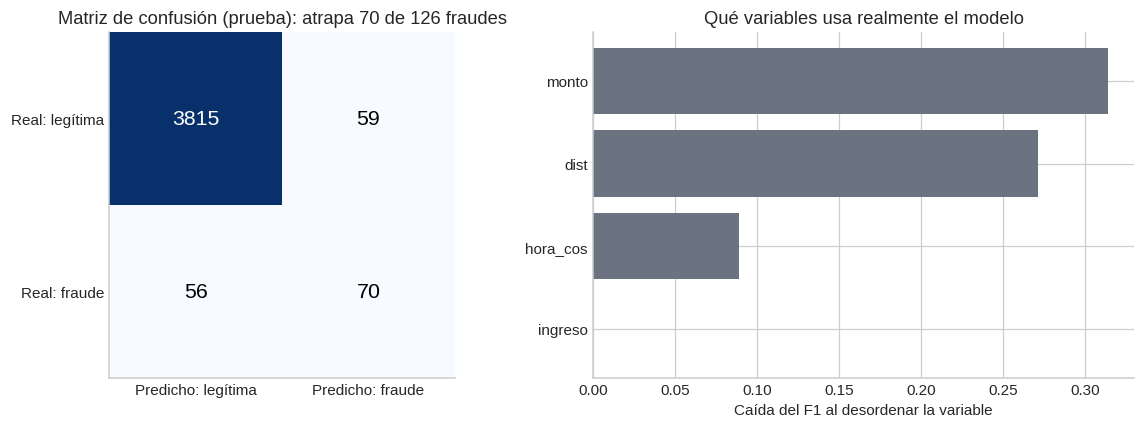

ingreso     0.000
hora_cos    0.089
dist        0.272
monto       0.314


In [ ]:
p = salida(mejor_fraude, Xte) > 0
cm = confusion_matrix(yte, p)
print("Matriz de confusión [[VN, FP], [FN, VP]]:", cm.tolist())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, f"{v}", ha="center", va="center", fontsize=14, color="white" if v > cm.max() / 2 else "black")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Predicho: legítima", "Predicho: fraude"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Real: legítima", "Real: fraude"])
axes[0].set_title(f"Matriz de confusión (prueba): atrapa {cm[1,1]} de {cm[1].sum()} fraudes")
axes[0].grid(False)

# Importancia por permutación (20 repeticiones por variable)
rng = np.random.default_rng(0)
base_f1 = f1_ind(mejor_fraude, Xte, yte)
imp = {}
for c in nombres:
    caidas = []
    for _ in range(20):
        Xp = Xte.copy(); Xp[c] = rng.permutation(Xp[c].values)
        caidas.append(base_f1 - f1_ind(mejor_fraude, Xp, yte))
    imp[c] = np.mean(caidas)
imp = pd.Series(imp).sort_values()
axes[1].barh(imp.index, imp.values, color="#6b7280")
axes[1].set_xlabel("Caída del F1 al desordenar la variable")
axes[1].set_title("Qué variables usa realmente el modelo")
plt.tight_layout(); guardar(fig, "matriz_confusion_e_importancia"); plt.show()
print(imp.round(3).to_string())

Otra mirada: cuántas veces aparece cada variable en el árbol elegido de cada corrida.

In [ ]:
uso = pd.DataFrame({f"semilla {c['seed']}": {v: len(re.findall(r"\b" + v + r"\b", str(c["ind"]))) for v in nombres} for c in corridas3}).T
uso.columns = [f"veces que aparece '{v}'" for v in nombres]
uso["F1 prueba"] = [round(c["F1"], 3) for c in corridas3]
uso

,veces que aparece 'monto',veces que aparece 'ingreso',veces que aparece 'dist',veces que aparece 'hora_cos',F1 prueba
semilla 0,4,1,3,1,0.564
semilla 1,2,1,2,2,0.541
semilla 2,3,2,4,1,0.559
semilla 3,5,0,5,3,0.549
semilla 4,3,2,2,1,0.526


### 3.6 Conclusiones del ejercicio 3


- **El primer archivo no servía.** Con todo al azar, hasta un modelo fuerte da AUC ~0.5: no hay nada que aprender. En la versión 2 sí hay señal, pero también ruido que nadie puede quitar (fraudes que se ven normales y viajes legítimos lejos de casa).
- **Resultado de la PG.** El árbol elegido por validación detecta **70 de los 126 fraudes** de la prueba (recall 0.56) y marca mal 59 de las 3,874 transacciones legítimas, lo que da una precisión de 0.54 y un F1 de **0.55**. Las otras corridas quedaron entre 0.53 y 0.56.
- **Contra los modelos clásicos.** Con las mismas variables, la regresión logística saca F1 0.51, el árbol de decisión 0.50 y gradient boosting 0.58. Con solo 126 fraudes en la prueba, diferencias de ±0.05 en F1 caen dentro del ruido, así que la PG queda **a la par**, no por encima. En AUC (0.83 contra ~0.88) queda por debajo: la PG optimizó el F1 con el umbral fijo en 0, no el orden de las transacciones.
- **Qué aprendió.** Pesan sobre todo el monto y la distancia, y en menor medida la madrugada (`hora_cos`), que es justo lo que se puso en el generador. El modelo elegido **no usa el ingreso**, o sea que no encontró la relación monto/ingreso. En 4 de las 5 corridas el ingreso sí aparece en el árbol, pero con un F1 parecido, así que en este archivo no cambió mucho el resultado.
- **Legibilidad.** La expresión se puede leer, pero tiene repeticiones (en la corrida elegida, `monto * dist` aparece tres veces).
- **Límites.** Los datos son sintéticos: el modelo recupera lo que se sembró y no dice nada del fraude real. Además hay una sola partición de los datos y solo 126 fraudes en prueba. En un caso real habría que definir el costo de un fraude que pasa frente al de bloquear una compra buena, partir los datos por fecha y no al azar, y fijar el umbral con esos costos.
- **Qué se podría probar después.** Darle a la PG el cociente monto/ingreso como terminal, subir el número de generaciones y usar una aptitud que refleje los costos.

## 4. Resumen, límites y referencias

### 4.1 Resumen de resultados

La tabla se calcula con las variables de las secciones anteriores.

In [ ]:
prom5 = np.mean([c["test"] for c in corridas])
resumen = pd.DataFrame([
    ["Ejercicio 2, robot", "Galletas entregadas en 50 salas nuevas (de 15)",
     f"{res['PG (mejor individuo)'].mean():.1f} (mejor corrida) | {prom5:.1f} (promedio de 5 corridas)",
     f"{res['Al azar'].mean():.1f} al azar | {res['Regla de la pared'].mean():.1f} regla de la pared"],
    ["Ejercicio 3, fraudes", "F1 en prueba (126 fraudes en 4,000 transacciones)",
     f"{comp.loc['PG (árbol evolucionado)', 'F1']:.2f} (recall {comp.loc['PG (árbol evolucionado)', 'Recall']:.2f}, precisión {comp.loc['PG (árbol evolucionado)', 'Precisión']:.2f})",
     f"{comp.loc['Regresión logística', 'F1']:.2f} regresión logística | {comp.loc['Gradient boosting (techo de referencia)', 'F1']:.2f} gradient boosting"],
], columns=["Ejercicio", "Métrica", "PG", "Referencias"])
resumen

,Ejercicio,Métrica,PG,Referencias
0,"Ejercicio 2, robot",Galletas entregadas en 50 salas nuevas (de 15),13.8 (mejor corrida) | 12.5 (promedio de 5 cor...,4.1 al azar | 5.4 regla de la pared
1,"Ejercicio 3, fraudes","F1 en prueba (126 fraudes en 4,000 transacciones)","0.55 (recall 0.56, precisión 0.54)",0.51 regresión logística | 0.58 gradient boosting


### 4.2 Límites generales

- Los dos problemas son **simulados**. Los resultados dependen de los supuestos elegidos (tamaño de sala, energía, porcentajes del generador de fraudes) y no se pueden extrapolar a casos reales.
- La PG es estocástica: otra semilla da otro programa. Por eso se reportan 5 corridas y no solo la mejor.
- Los parámetros (población, generaciones, probabilidades) se fijaron a mano, sin una búsqueda sistemática.
- Los resultados pueden cambiar un poco con otras versiones de las librerías, aunque las semillas sean las mismas.

### 4.3 Referencias

- Martínez, J. J. *4. Programación Genética. Conceptos básicos* (guía del curso).
- Koza, J. R. (1992). *Genetic Programming: On the Programming of Computers by Means of Natural Selection.* MIT Press. (Origen del problema de la hormiga artificial.)
- Langdon, W. B. y Poli, R. (2002). *Foundations of Genetic Programming.* Springer.
- Fortin, F.-A., De Rainville, F.-M., Gardner, M.-A., Parizeau, M. y Gagné, C. (2012). *DEAP: Evolutionary Algorithms Made Easy.* Journal of Machine Learning Research, 13, 2171-2175.